# 01 Data Exploration



## Business Problem

A Portuguese banking institution wants to understand which customers are likely to subscribe to a term deposit after being contacted. This is a realistic campaign-prioritization problem: the model should help decide which customers are most promising for a future campaign.

In this project, we use historical customer data to explore one central question:

> Can we predict whether a customer will subscribe to a term deposit based on demographic, financial and campaign-related information available before contact?

At this stage, we first inspect the raw data and collect observations that will guide data cleaning, feature engineering, and baseline training.

## Dataset Story

The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y). The target column is `y`, which tells us whether the customer subscribed or not. 
The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed.

Dataset: `bank-full.csv` with all examples and 17 inputs, ordered by date (older version of this dataset with less inputs). 

The dataset combines several types of information:

- Customer attributes: `age`, `job`, `marital`, `education`
- Account information: `default`, `balance`, `housing`, `loan`
- Call information: `contact`, `day`, `month`, `duration`, `campsign`, `pdays`, `previous`, `poutcome`
- Target variable: `y`

The variable *duration* is included in the raw data but is only known after the call. Therefore, it will be excluded from the predictive model to avoid data leakage.

From a machine learning perspective, this is a binary classification problem:

- `y = Yes`: client subscribed to a term deposit
- `y = No`: client did not subscribe to a term deposit

The exploration should answer practical questions before modeling:

- How many clients and columns do we have?
- Is the target variable balanced?
- Which columns are numeric and which are categorical?
- Are there missing, blank, duplicated, or incorrectly typed values?
- Which customer groups show higher subscription rates?

## Variable Definitions

These definitions describe the raw columns. This information is collected before the technical analysis.

| Variable | Definition |
| --- | --- |
| `age` | Age of the client. |
| `job` | Type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown') |
| `marital` | Marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed) |
| `education` | Highest education level (categorical variable)	|
| `default` | Has credit in default? |
| `balance` | Average yearly balance |
| `housing` | Has housing loan? |
| `loan` | Has personal loan? |
| `contact` | contact communication type (categorical: 'cellular','telephone') |
| `day` | Day of the month when the last contact occurred. |
| `month` | Last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec') |
| `duration` | Last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model. |
| `campaign` | Number of contacts performed during this campaign and for this client (numeric, includes last contact)   |
| `pdays` | Number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted) |
| `previous` | Number of contacts performed before this campaign and for this client |
| `poutcome` | Outcome of the previous marketing campaign (categorical: 'failure','other','nonexistent','success').  |
| `y` | Target variable:	has the client subscribed a term deposit? (`Yes`, `No`). |

The variables can be grouped into four main business domains:

- Customer demographics:  age, job, marital, education  
- Customer financial status:  default, balance, housing, loan  
- Marketing campaign history: contact, day, month, campaign, pdays, previous, poutcome  
- Target variable:  y (term deposit subscription)  

Note: The variable 'duration' is intentionally not assigned to any business group because it is only available after the phone call has finished. It will therefore be treated as a leakage variable and excluded from the predictive model.

## Notebook Scope

This notebook focuses only on exploration:

- Load the raw Bank Marketing dataset.
- Understand rows, columns, data types, and basic distributions.
- Inspect the target variable `y`.
- Identify data quality issues that should be handled during data cleaning.

This notebook does not train a model yet and does not modify the raw data.

## 1. Setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "raw" / "bank-full.csv").exists():
            return path
    raise FileNotFoundError("Could not find project root with data/raw/bank-full.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank-full.csv"

print(f"Project root: {PROJECT_ROOT}")
DATA_PATH

Project root: /home/patri/master/ads2-bank-marketing-project


PosixPath('/home/patri/master/ads2-bank-marketing-project/data/raw/bank-full.csv')

## 2. Load Raw Data

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Raw data file not found: {DATA_PATH}\n"
        "Expected path: data/raw/bank-full.csv"
    )

df = pd.read_csv(DATA_PATH, sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 45,211
Columns: 17


## 3. Column Overview

In [6]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [9]:
for col in ["job", "marital", "education", "contact", "poutcome"]:
    print(f"\n{col}")
    print(sorted(df[col].unique()))


job
['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

marital
['divorced', 'married', 'single']

education
['primary', 'secondary', 'tertiary', 'unknown']

contact
['cellular', 'telephone', 'unknown']

poutcome
['failure', 'other', 'success', 'unknown']


### Key Observations

- There are no missing values.
- All variables were imported with appropriate data types.
- The dataset contains 17 variables: 7 numerical features and 10 categorical features.
- No NaN values were detected after loading the dataset.
- The variable `duration` represents the duration of the last contact with the client. Since this information is only available after the phone call has ended, using it as a predictor would introduce data leakage. Therefore, it will not be used when training the predictive model.

## 4. Target Variable

In [11]:
target_counts = df["y"].value_counts()
target_share = df["y"].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({
    "count": target_counts,
    "share_percent": target_share,
})

,count,share_percent
y,,
no,39922,88.3
yes,5289,11.7


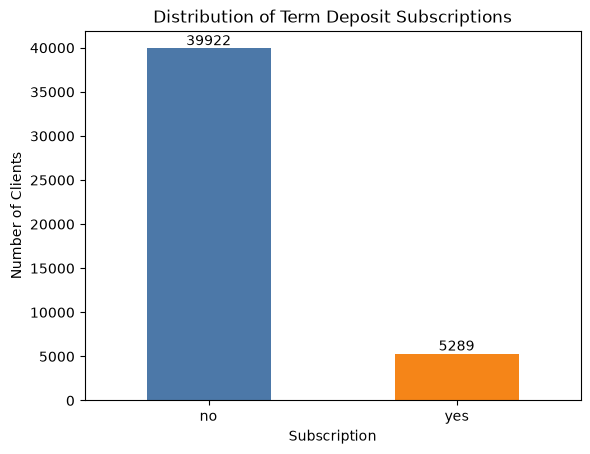

In [14]:
ax = target_counts.plot(kind="bar", color=["#4C78A8", "#F58518"])
ax.set_title("Distribution of Term Deposit Subscriptions")
ax.set_xlabel("Subscription")
ax.set_ylabel("Number of Clients")
plt.xticks(rotation=0)
# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.show()

**Class distribution:**  
no = 88.3%  
yes = 11.7%

#### Key Observations

- The target variable is highly imbalanced.
- Approximately 88% of the clients did not subscribe to a term deposit.
- Accuracy alone would be misleading for model evaluation.
- Metrics such as Precision, Recall, F1-score and ROC AUC will therefore be considered.

## 5. Missing Values and Duplicates

In [15]:
missing_summary = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_share_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)
missing_summary.sort_values("missing_count", ascending=False)

,missing_count,missing_share_percent
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


In [17]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


#### Key Observations

- No `NaN` values were found in the raw dataset.
- No duplicated rows were found in the raw dataset.
- Therefore, no duplicate records need to be removed during the data cleaning stage.
- Special values such as `"unknown"` and `pdays = -1` will be examined separately.

## 6. Data Type Checks

In [18]:
dtype_summary = (
    df.dtypes
    .rename("dtype")
    .to_frame()
    .assign(unique_values=df.nunique())
)
dtype_summary

,dtype,unique_values
age,int64,77
job,object,12
marital,object,3
education,object,4
default,object,2
balance,int64,7168
housing,object,2
loan,object,2
contact,object,3
day,int64,31


#### Key Observations

- All variables appear to have appropriate data types after loading the dataset.
- Numerical variables were correctly imported as integers.
- Categorical variables were imported as text ('object'), which is expected.
- No immediate data type corrections are required.
- Categorical variables will be encoded later during the feature engineering stage before model training.

In [19]:
unknown_summary = []

for column in df.select_dtypes(include="object").columns:

    unknown_count = (df[column] == "unknown").sum()

    if unknown_count > 0:

        unknown_summary.append({
            "column": column,
            "unknown_count": unknown_count,
            "unknown_share_percent": round(
                unknown_count / len(df) * 100,
                2
            )
        })

pd.DataFrame(unknown_summary)

,column,unknown_count,unknown_share_percent
0,job,288,0.64
1,education,1857,4.11
2,contact,13020,28.80
3,poutcome,36959,81.75


#### Key Observations

- The category `"unknown"` appears in four categorical variables.
- The share of unknown values varies considerably across variables.
- `job` (0.64%) and `education` (4.11%) contain relatively few unknown values.
- `contact` contains a substantial proportion of unknown values (28.80%).
- `poutcome` contains a very high proportion of unknown values (81.75%). Maybe information about previous campaign outcomes is unavailable for most clients.
- The treatment of these special values will be decided during the data cleaning and feature engineering stages.

In [20]:
pdays_minus1_count = (df["pdays"] == -1).sum()
pdays_minus1_share = round(pdays_minus1_count / len(df) * 100, 2)

print(f"Clients with pdays = -1: {pdays_minus1_count:,}")
print(f"Share of dataset: {pdays_minus1_share}%")

Clients with pdays = -1: 36,954
Share of dataset: 81.74%


#### Key Observations

- The value `-1` in `pdays` is a special code rather than a valid number of days.
- It indicates that the client had not been contacted in a previous marketing campaign.
- A total of 36,954 clients (81.74%) have `pdays = -1`, meaning that most clients had no previous campaign contact.
- This result is consistent with the high proportion of `"unknown"` values observed in `poutcome`, since a previous campaign outcome cannot exist if no previous contact occurred.
- The representation of these special values will be reviewed during feature engineering.

## 7. Numerical Features

This section explores the numerical variables in the dataset.  

The objective is to understand their distributions, identify potential outliers, and detect characteristics that may influence later preprocessing and model development.


In [21]:
numeric_columns = ["age", "balance", "duration", "campaign", "pdays", "previous"]

numeric_summary = df[numeric_columns].describe().T
numeric_summary


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


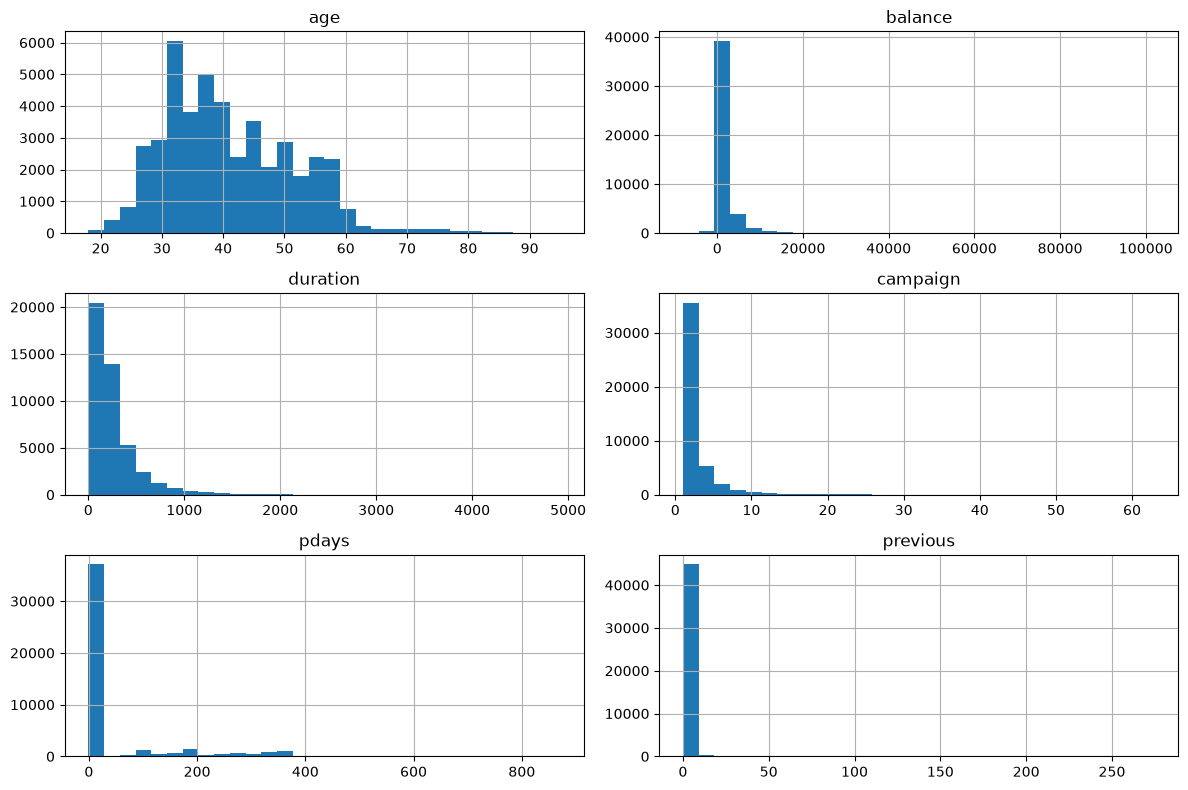

In [23]:
df[numeric_columns].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()


#### Key Observations

- `age` is concentrated mainly between 30 and 50 years, with relatively few very young or elderly clients.
- `balance` is highly right-skewed, with a small number of clients having very large account balances.
- `duration` is also strongly right-skewed. Although it is included for exploration, it will not be used for prediction because it introduces data leakage.
- Most clients were contacted only a few times (`campaign`), while a small number received many contact attempts.
- The distribution of `pdays` is dominated by the special value `-1`, indicating that most clients had not been contacted in a previous campaign.
- The variable `previous` is concentrated around zero, showing that most clients had little or no previous campaign history.

## 8. Categorical Features

This section explores the categorical variables in the dataset.

The objective is to understand the distribution of categories and identify dominant classes, special values, or unusual patterns that may influence later preprocessing and feature engineering.

The categorical variables include customer characteristics, financial information, and campaign-related features such as `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, and `poutcome`.

For exploration, we inspect the frequency of each category and later compare selected categories with the target variable `y`.

In [24]:
categorical_columns = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

In [25]:
for column in categorical_columns:
    print(f"\n{'='*50}")
    print(column.upper())
    print(df[column].value_counts())


JOB
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

MARITAL
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

EDUCATION
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

DEFAULT
default
no     44396
yes      815
Name: count, dtype: int64

HOUSING
housing
yes    25130
no     20081
Name: count, dtype: int64

LOAN
loan
no     37967
yes     7244
Name: count, dtype: int64

CONTACT
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

MONTH
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count

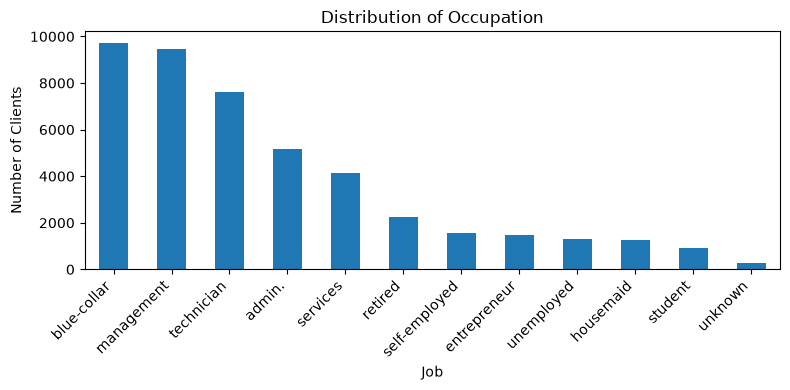

In [26]:
ax = df["job"].value_counts().plot(
    kind="bar",
    figsize=(8, 4)
)

ax.set_title("Distribution of Occupation")
ax.set_xlabel("Job")
ax.set_ylabel("Number of Clients")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

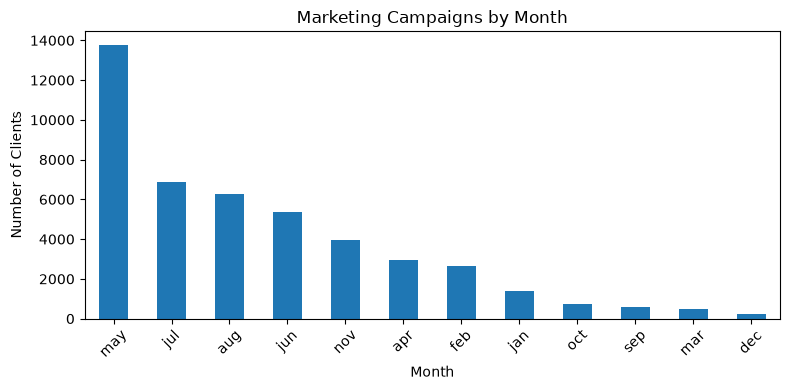

In [27]:
ax = df["month"].value_counts().plot(
    kind="bar",
    figsize=(8,4)
)

ax.set_title("Marketing Campaigns by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Clients")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

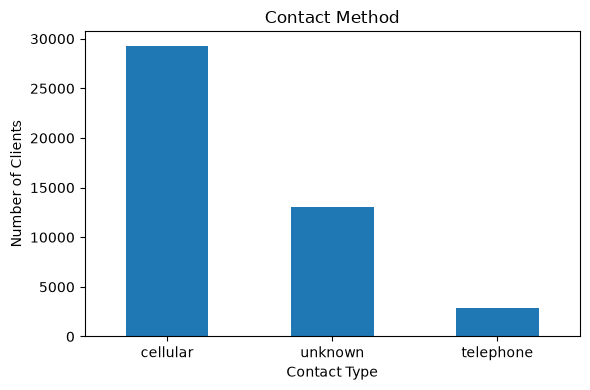

In [28]:
ax = df["contact"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

ax.set_title("Contact Method")
ax.set_xlabel("Contact Type")
ax.set_ylabel("Number of Clients")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

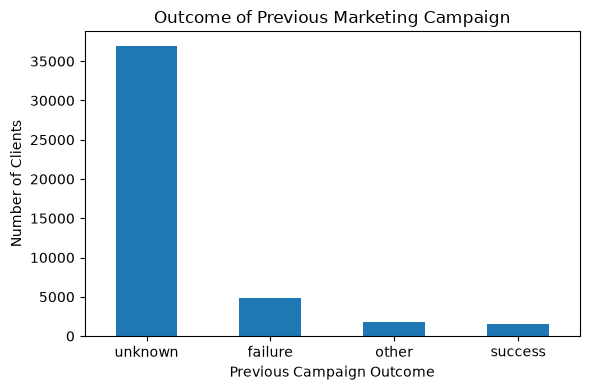

In [29]:
ax = df["poutcome"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

ax.set_title("Outcome of Previous Marketing Campaign")
ax.set_xlabel("Previous Campaign Outcome")
ax.set_ylabel("Number of Clients")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Initial Findings

The exploratory analysis provided an initial understanding of the Bank Marketing dataset.

Main findings include:

- The dataset contains no missing values or duplicated records.
- Several variables contain special values (`unknown` and `-1`) that require careful treatment.
- The target variable is clearly imbalanced.
- Numerical variables such as `balance`, `duration`, and `campaign` are highly right-skewed.
- Marketing campaigns were concentrated in a few months rather than being evenly distributed across the year.
- The feature `duration` represents data leakage and will therefore not be used for predictive modelling.
- Further preprocessing and feature engineering will be performed in the following notebook.

## 10. Conversion by Selected Features

In [30]:
def conversion_rate_by(column: str) -> pd.DataFrame:
    return (
        df.groupby(column)["y"]
        .value_counts(normalize=True)
        .mul(100)
        .rename("share_percent")
        .reset_index()
        .pivot(index=column, columns="y", values="share_percent")
        .round(2)
        .sort_values("yes", ascending=False)
    )

In [31]:
conversion_rate_by("poutcome")

y,no,yes
poutcome,,
success,35.27,64.73
other,83.32,16.68
failure,87.39,12.61
unknown,90.84,9.16


In [32]:
conversion_rate_by("contact")

y,no,yes
contact,,
cellular,85.08,14.92
telephone,86.58,13.42
unknown,95.93,4.07


In [33]:
conversion_rate_by("month")

y,no,yes
month,,
mar,48.01,51.99
dec,53.27,46.73
sep,53.54,46.46
oct,56.23,43.77
apr,80.32,19.68
feb,83.35,16.65
aug,88.99,11.01
jun,89.78,10.22
nov,89.85,10.15


In [34]:
conversion_rate_by("job")

y,no,yes
job,,
student,71.32,28.68
retired,77.21,22.79
unemployed,84.50,15.50
management,86.24,13.76
admin.,87.80,12.20
self-employed,88.16,11.84
unknown,88.19,11.81
technician,88.94,11.06
services,91.12,8.88


#### Key Observations

- Clients with a successful previous campaign outcome have the highest subscription rate.
- Students and retired clients show higher conversion rates than most other occupational groups.
- Campaign month appears to influence conversion rates, suggesting possible seasonality.
- Clients with an unknown previous campaign outcome have the lowest conversion probability.

## 11. Exploration Summary

Key findings from this exploratory analysis:

- The dataset contains 45,211 observations and 17 variables.
- No missing values or duplicated records were detected.
- The target variable is imbalanced (88.3% "no", 11.7% "yes").
- `duration` introduces data leakage and will be excluded from model training.
- Special values such as `"unknown"` and `-1` require careful handling during preprocessing.
- Several numerical variables are highly right-skewed and contain extreme values.
- Previous campaign information (`poutcome` and `pdays`) appears to be strongly associated with subscription outcomes.

Next notebook:
- Data cleaning and preprocessing.